# Análisis de sentimiento

In [1]:
%pip install pysentimiento networkx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 22.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 658.5/658.5 kB 14.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 791.9/791.9 kB 19.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 22.5 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 21.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20/20 [pysentimiento]0m [transformers]

[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Importaciones y carga de datos

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from pathlib import Path
from collections import Counter
from tqdm.auto import tqdm

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 100)

sns.set_theme(style="whitegrid", palette="colorblind")


def localizar_archivo(nombre):
    rutas = [
        Path("data") / nombre,
        Path(nombre)
    ]

    for ruta in rutas:
        if ruta.exists():
            return ruta

    raise FileNotFoundError(
        f"No se encontró {nombre}. "
        "Colócalo en la carpeta data o junto al notebook."
    )


ruta_videos = localizar_archivo("youtube_videos_clean.csv")
ruta_comments = localizar_archivo("youtube_comments_clean.csv")

videos = pd.read_csv(ruta_videos, encoding="utf-8-sig")
comments = pd.read_csv(ruta_comments, encoding="utf-8-sig")

print(f"Videos: {videos.shape[0]} filas")
print(f"Comentarios: {comments.shape[0]} filas")
print(f"Autores únicos: {comments['author_channel_id'].nunique()}")
print(f"Videos comentados: {comments['video_id'].nunique()}")

Videos: 293 filas
Comentarios: 406 filas
Autores únicos: 332
Videos comentados: 19


## Vlaidación del texto

In [3]:
columna_texto = (
    "texto_original"
    if "texto_original" in comments.columns
    else "text"
)

comments["texto_sentimiento"] = (
    comments[columna_texto]
    .fillna(comments["text"])
    .fillna("")
    .astype(str)
    .str.strip()
)

print(f"Columna utilizada: {columna_texto}")
print(
    "Comentarios vacíos:",
    comments["texto_sentimiento"].eq("").sum()
)

display(
    comments[
        ["comment_id", "texto_sentimiento"]
    ].head()
)

Columna utilizada: texto_original
Comentarios vacíos: 0


,comment_id,texto_sentimiento
0,Ugw-J65a1iYL9hqhELh4AaABAg,Ese corrupto amigo de la vieja fiscal los tengo que verbose en la carcel
1,Ugw-ZT9t9wU2V-tCaUZ4AaABAg,"Están jóvenes porque no buscan un trabajo, tuvieron suerte que no hay policías que le gusta del..."
2,Ugw0xaOb2CYXXoudtwJ4AaABAg,"Me dejaron con ganas de demandar la ilegalidad de las reuniones virtuales, esto no es una maquila"
3,Ugw0xgUc2ISpBr5_T654AaABAg,Veremos a este mafioso de Mazariegos en la cárcel y un buen tiempo en la sombra.
4,Ugw1ZzA21njWhaqQQTh4AaABAg,eso es para que salga de USA por su propio pie \nque se auto deporten


## Carga del modelo

In [4]:
from pysentimiento import create_analyzer

analizador = create_analyzer(
    task="sentiment",
    lang="es"
)

print("Modelo cargado correctamente.")

config.json:   0%|          | 0.00/925 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/435M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

Modelo cargado correctamente.


## Calificación de los comentarios

In [5]:
resultados = []

for texto in tqdm(
    comments["texto_sentimiento"],
    desc="Analizando comentarios"
):
    prediccion = analizador.predict(texto)

    resultados.append({
        "sentimiento_codigo": prediccion.output,
        "prob_negativo": prediccion.probas["NEG"],
        "prob_neutral": prediccion.probas["NEU"],
        "prob_positivo": prediccion.probas["POS"],
        "confianza_sentimiento": max(
            prediccion.probas.values()
        )
    })


resultados = pd.DataFrame(resultados)

comments = pd.concat(
    [
        comments.reset_index(drop=True),
        resultados.reset_index(drop=True)
    ],
    axis=1
)


etiquetas = {
    "NEG": "Negativo",
    "NEU": "Neutral",
    "POS": "Positivo"
}

comments["sentimiento"] = (
    comments["sentimiento_codigo"]
    .map(etiquetas)
)

display(
    comments[
        [
            "texto_sentimiento",
            "sentimiento",
            "prob_negativo",
            "prob_neutral",
            "prob_positivo",
            "confianza_sentimiento"
        ]
    ].head(10)
)

Analizando comentarios:   0%|          | 0/406 [00:00<?, ?it/s]

,texto_sentimiento,sentimiento,prob_negativo,prob_neutral,prob_positivo,confianza_sentimiento
0,Ese corrupto amigo de la vieja fiscal los tengo que verbose en la carcel,Negativo,0.807787,0.146285,0.045928,0.807787
1,"Están jóvenes porque no buscan un trabajo, tuvieron suerte que no hay policías que le gusta del...",Negativo,0.965087,0.029080,0.005833,0.965087
2,"Me dejaron con ganas de demandar la ilegalidad de las reuniones virtuales, esto no es una maquila",Negativo,0.971377,0.025967,0.002656,0.971377
3,Veremos a este mafioso de Mazariegos en la cárcel y un buen tiempo en la sombra.,Negativo,0.701865,0.267648,0.030487,0.701865
4,eso es para que salga de USA por su propio pie \nque se auto deporten,Negativo,0.810328,0.170431,0.019241,0.810328
5,Imagine if they had to walk back home.,Neutral,0.308975,0.539604,0.151421,0.539604
6,buenísima investigacion :hand-purple-blue-peace::hand-purple-blue-peace::hand-purple-blue-peace:,Positivo,0.021916,0.388819,0.589265,0.589265
7,"Lleven su lonchera, sacrifiquense un poco. Y reintevren ese dinero. O están robando.",Negativo,0.583548,0.376686,0.039767,0.583548
8,Viva Guatemala 🇬🇹🇬🇹🇬🇹🥳🥳🥳,Neutral,0.157945,0.677143,0.164912,0.677143
9,LADRONES !!!!,Negativo,0.581595,0.289842,0.128563,0.581595


In [6]:
resumen_general = (
    comments["sentimiento"]
    .value_counts()
    .reindex(
        ["Negativo", "Neutral", "Positivo"],
        fill_value=0
    )
    .rename_axis("sentimiento")
    .reset_index(name="comentarios")
)

resumen_general["proporcion"] = (
    resumen_general["comentarios"]
    / resumen_general["comentarios"].sum()
)

resumen_general["porcentaje"] = (
    resumen_general["proporcion"]
    .map(lambda valor: f"{valor:.1%}")
)

display(resumen_general)

,sentimiento,comentarios,proporcion,porcentaje
0,Negativo,249,0.613300,61.3%
1,Neutral,79,0.194581,19.5%
2,Positivo,78,0.192118,19.2%


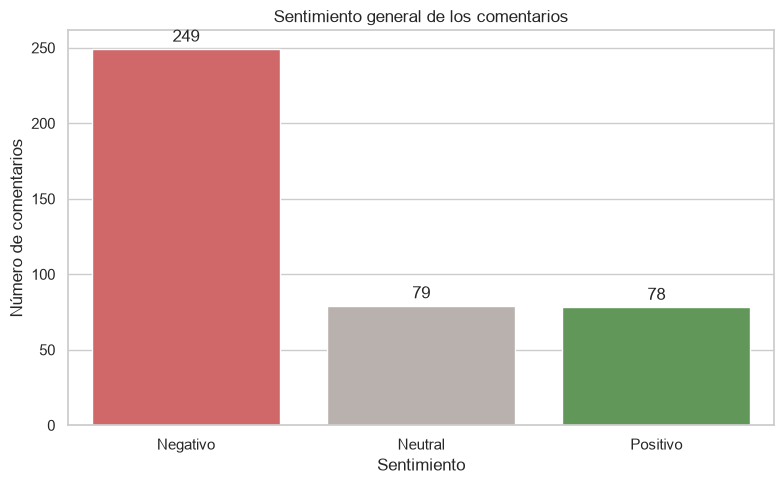

In [7]:
colores = {
    "Negativo": "#E15759",
    "Neutral": "#BAB0AC",
    "Positivo": "#59A14F"
}

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=resumen_general,
    x="sentimiento",
    y="comentarios",
    hue="sentimiento",
    palette=colores,
    legend=False
)

for contenedor in ax.containers:
    ax.bar_label(contenedor, padding=3)

plt.title("Sentimiento general de los comentarios")
plt.xlabel("Sentimiento")
plt.ylabel("Número de comentarios")
plt.tight_layout()
plt.show()

## Función de comparación

In [8]:
MIN_COMENTARIOS = 10
ORDEN_SENTIMIENTO = [
    "Negativo",
    "Neutral",
    "Positivo"
]


def comparar_sentimiento(datos, columnas_grupo):
    tabla = (
        datos.groupby(
            columnas_grupo + ["sentimiento"]
        )
        .size()
        .unstack(fill_value=0)
        .reindex(
            columns=ORDEN_SENTIMIENTO,
            fill_value=0
        )
    )

    tabla["total"] = tabla[
        ORDEN_SENTIMIENTO
    ].sum(axis=1)

    tabla = (
        tabla.query("total >= @MIN_COMENTARIOS")
        .sort_values("total", ascending=False)
    )

    porcentajes = (
        tabla[ORDEN_SENTIMIENTO]
        .div(tabla["total"], axis=0)
        .mul(100)
    )

    return tabla, porcentajes

### Comparación por video

sentimiento,video_id,video_title,Negativo,Neutral,Positivo,total
0,n8iP75gIpmw,Qué rico come tu diputado,130,22,9,161
1,j43HgwYFKfk,La cooptación de Walter Mazariegos en la USAC,29,11,10,50
2,6W4u8sGEnGM,Inician los trabajos de recuperación del Puente Belice II.,18,14,13,45
3,OkXlHx0hx-8,EE.UU. envía a mexicanos deportados a Guatemala antes de su regreso a México | Noticias Telemundo,16,7,2,25
4,PjmxCj-a9Hg,Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt,17,4,4,25
5,lj983NWyAQY,Plan 2032 Ciudad de Guatemala,2,3,20,25
6,yLZS3JiEBg8,Arroz con pollo a la MONOPOLIO,9,2,5,16
7,06mFNPU0aB8,Capturan a presuntos delincuentes disfrazados de mujer señalados de cometer asalto,4,7,3,14
8,ndAZjHqzzT8,Internet: escoger el menos malo,4,4,4,12


,sentimiento,Negativo,Neutral,Positivo
video_id,video_title,,,
n8iP75gIpmw,Qué rico come tu diputado,80.7,13.7,5.6
j43HgwYFKfk,La cooptación de Walter Mazariegos en la USAC,58.0,22.0,20.0
6W4u8sGEnGM,Inician los trabajos de recuperación del Puente Belice II.,40.0,31.1,28.9
OkXlHx0hx-8,EE.UU. envía a mexicanos deportados a Guatemala antes de su regreso a México | Noticias Telemundo,64.0,28.0,8.0
PjmxCj-a9Hg,Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt,68.0,16.0,16.0
lj983NWyAQY,Plan 2032 Ciudad de Guatemala,8.0,12.0,80.0
yLZS3JiEBg8,Arroz con pollo a la MONOPOLIO,56.2,12.5,31.2
06mFNPU0aB8,Capturan a presuntos delincuentes disfrazados de mujer señalados de cometer asalto,28.6,50.0,21.4
ndAZjHqzzT8,Internet: escoger el menos malo,33.3,33.3,33.3


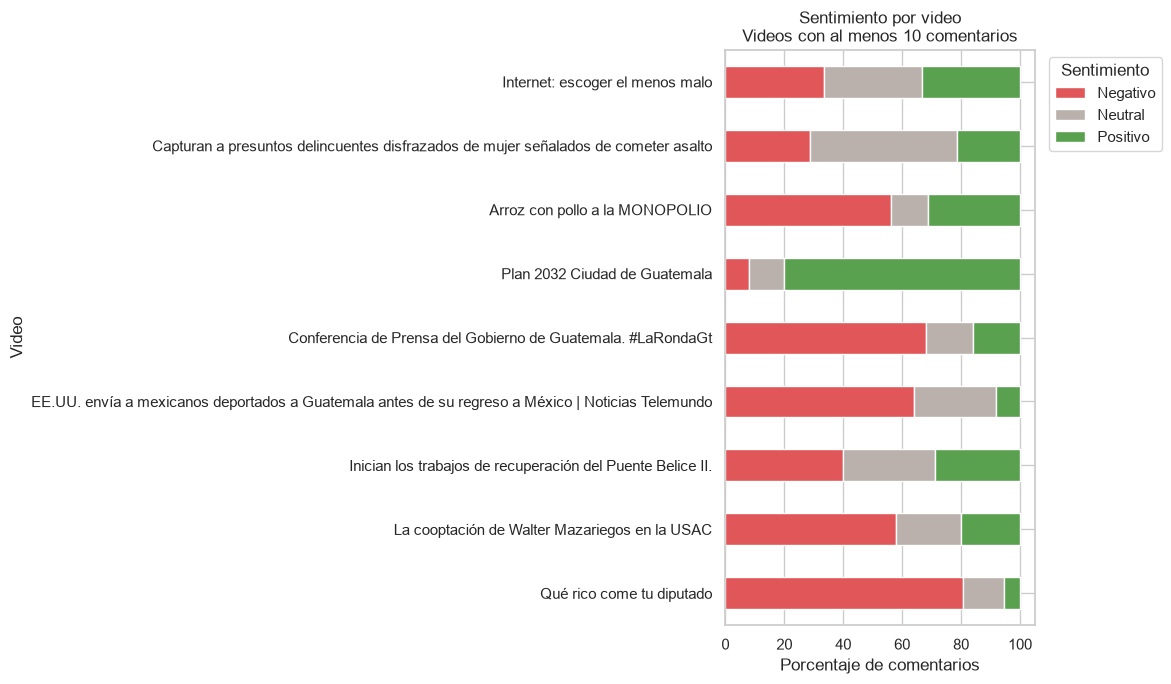

In [9]:
sentimiento_video, porcentaje_video = comparar_sentimiento(
    comments,
    ["video_id", "video_title"]
)

display(sentimiento_video.reset_index())
display(porcentaje_video.round(1))

porcentaje_video.index = [
    titulo
    for _, titulo in porcentaje_video.index
]

porcentaje_video.plot(
    kind="barh",
    stacked=True,
    figsize=(12, 7),
    color=[colores[x] for x in ORDEN_SENTIMIENTO]
)

plt.title(
    "Sentimiento por video\n"
    f"Videos con al menos {MIN_COMENTARIOS} comentarios"
)
plt.xlabel("Porcentaje de comentarios")
plt.ylabel("Video")
plt.legend(
    title="Sentimiento",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

### Comparación por canal

sentimiento,channel_id,channel_name,Negativo,Neutral,Positivo,total
0,UCE4rsXcgDb6e1-a9iTbWzfg,Quorum,179,41,36,256
1,UC-ZtFBHzgkYFh7whZkuR_Ag,Gobierno de la República de Guatemala,35,18,17,70
2,UCRwA1NUcUnwsly35ikGhp0A,Noticias Telemundo,16,7,2,25
3,UCXa6LVjBzUtmcM3cwbd9e2w,Municipalidad de Guatemala,2,3,20,25
4,UCVpSRoZgngfSL03Nlbjtq9A,Noti7,4,7,3,14


,sentimiento,Negativo,Neutral,Positivo
channel_id,channel_name,,,
UCE4rsXcgDb6e1-a9iTbWzfg,Quorum,69.9,16.0,14.1
UC-ZtFBHzgkYFh7whZkuR_Ag,Gobierno de la República de Guatemala,50.0,25.7,24.3
UCRwA1NUcUnwsly35ikGhp0A,Noticias Telemundo,64.0,28.0,8.0
UCXa6LVjBzUtmcM3cwbd9e2w,Municipalidad de Guatemala,8.0,12.0,80.0
UCVpSRoZgngfSL03Nlbjtq9A,Noti7,28.6,50.0,21.4


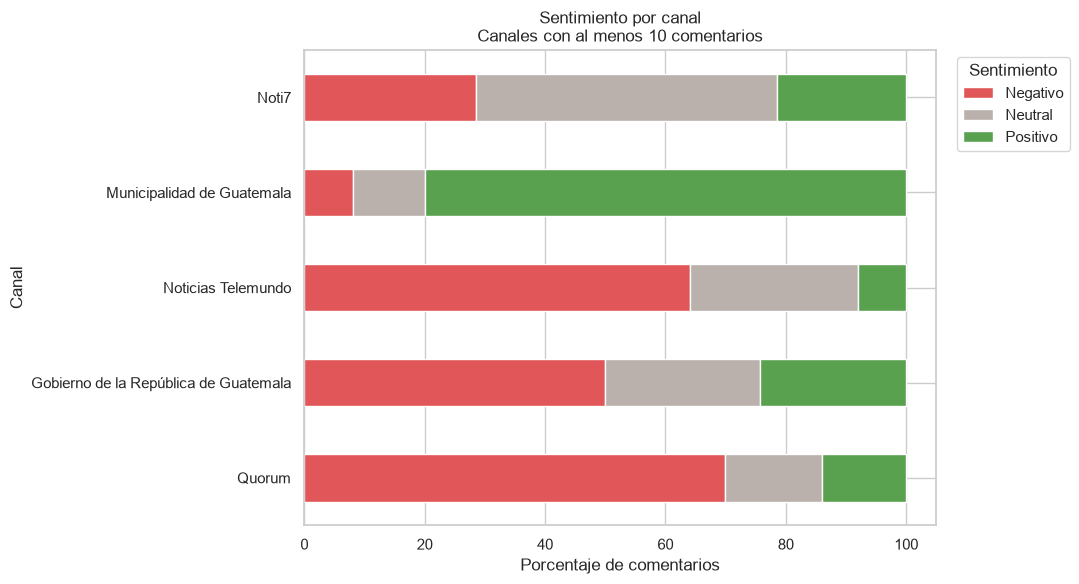

In [10]:
sentimiento_canal, porcentaje_canal = comparar_sentimiento(
    comments,
    ["channel_id", "channel_name"]
)

display(sentimiento_canal.reset_index())
display(porcentaje_canal.round(1))

porcentaje_canal.index = [
    nombre
    for _, nombre in porcentaje_canal.index
]

porcentaje_canal.plot(
    kind="barh",
    stacked=True,
    figsize=(11, 6),
    color=[colores[x] for x in ORDEN_SENTIMIENTO]
)

plt.title(
    "Sentimiento por canal\n"
    f"Canales con al menos {MIN_COMENTARIOS} comentarios"
)
plt.xlabel("Porcentaje de comentarios")
plt.ylabel("Canal")
plt.legend(
    title="Sentimiento",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

### Comparación por consulta o tema

sentimiento,source_query,Negativo,Neutral,Positivo,total
0,@quorumgt/videos,166,37,28,231
1,guatemala noticias,33,17,5,55
2,Gobierno de la República de Guatemala,18,14,13,45
3,@GobiernodeGuatemala,17,4,4,25
4,@quorumgt,13,4,8,25
5,Municipalidad de Guatemala,2,3,20,25


sentimiento,Negativo,Neutral,Positivo
source_query,,,
@quorumgt/videos,71.9,16.0,12.1
guatemala noticias,60.0,30.9,9.1
Gobierno de la República de Guatemala,40.0,31.1,28.9
@GobiernodeGuatemala,68.0,16.0,16.0
@quorumgt,52.0,16.0,32.0
Municipalidad de Guatemala,8.0,12.0,80.0


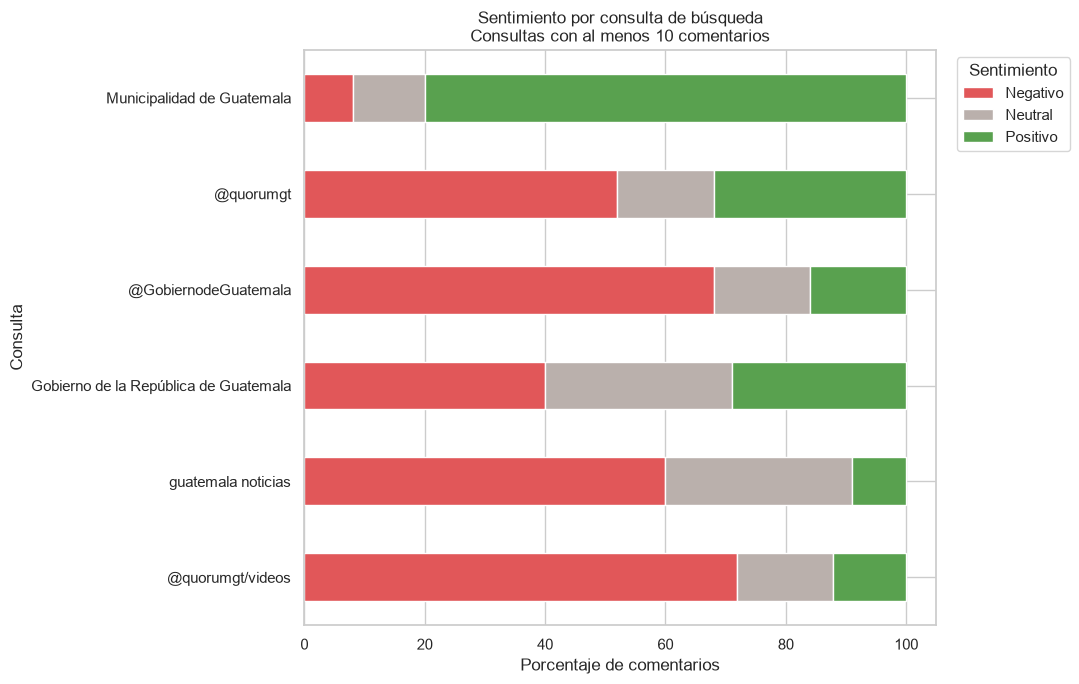

In [11]:
sentimiento_tema, porcentaje_tema = comparar_sentimiento(
    comments,
    ["source_query"]
)

display(sentimiento_tema.reset_index())
display(porcentaje_tema.round(1))

porcentaje_tema.plot(
    kind="barh",
    stacked=True,
    figsize=(11, 7),
    color=[colores[x] for x in ORDEN_SENTIMIENTO]
)

plt.title(
    "Sentimiento por consulta de búsqueda\n"
    f"Consultas con al menos {MIN_COMENTARIOS} comentarios"
)
plt.xlabel("Porcentaje de comentarios")
plt.ylabel("Consulta")
plt.legend(
    title="Sentimiento",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

## Reconstrucción red

In [12]:
aristas = (
    comments.groupby(
        ["author_channel_id", "video_id"],
        as_index=False
    )
    .agg(
        peso=("comment_id", "nunique")
    )
)

B = nx.Graph()

for fila in aristas.itertuples(index=False):
    autor = f"autor::{fila.author_channel_id}"
    video = f"video::{fila.video_id}"

    B.add_node(
        autor,
        tipo="autor",
        id_original=fila.author_channel_id
    )

    B.add_node(
        video,
        tipo="video",
        id_original=fila.video_id
    )

    B.add_edge(
        autor,
        video,
        weight=fila.peso
    )

print(f"Nodos: {B.number_of_nodes()}")
print(f"Aristas: {B.number_of_edges()}")

Nodos: 351
Aristas: 343


In [13]:
comunidades = nx.community.louvain_communities(
    B,
    weight="weight",
    seed=42,
    resolution=1.0
)

comunidades = sorted(
    comunidades,
    key=len,
    reverse=True
)

modularidad = nx.community.modularity(
    B,
    comunidades,
    weight="weight"
)

video_a_comunidad = {}

for numero, comunidad in enumerate(comunidades):
    for nodo in comunidad:
        if B.nodes[nodo]["tipo"] == "video":
            video_id = B.nodes[nodo]["id_original"]
            video_a_comunidad[video_id] = numero

comments["comunidad"] = (
    comments["video_id"]
    .map(video_a_comunidad)
)

print(f"Comunidades encontradas: {len(comunidades)}")
print(f"Modularidad: {modularidad:.4f}")
print(
    "Comentarios sin comunidad:",
    comments["comunidad"].isna().sum()
)

Comunidades encontradas: 17
Modularidad: 0.7774
Comentarios sin comunidad: 0


### Sentimiento por comunidad

sentimiento,comunidad,Negativo,Neutral,Positivo,total
0,0,130,22,9,161
1,1,29,11,10,50
2,3,18,14,13,45
3,2,17,8,9,34
4,4,2,3,20,25
5,5,16,7,2,25
6,6,17,4,4,25
7,7,4,7,3,14


sentimiento,Negativo,Neutral,Positivo
comunidad,,,
0,80.7,13.7,5.6
1,58.0,22.0,20.0
3,40.0,31.1,28.9
2,50.0,23.5,26.5
4,8.0,12.0,80.0
5,64.0,28.0,8.0
6,68.0,16.0,16.0
7,28.6,50.0,21.4


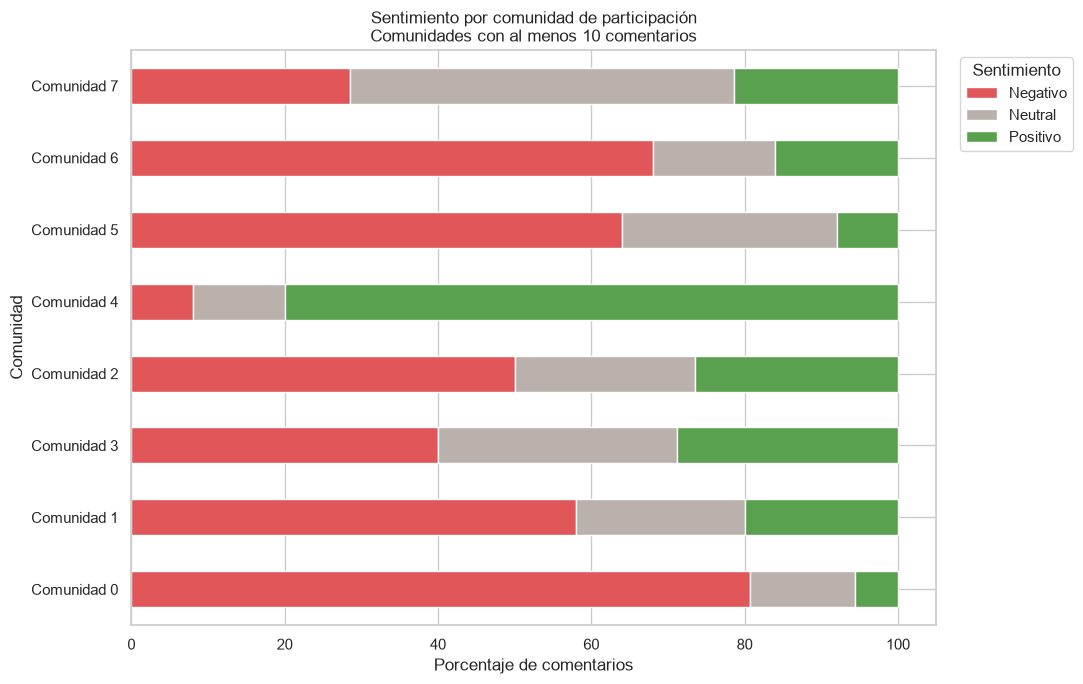

In [14]:
sentimiento_comunidad, porcentaje_comunidad = (
    comparar_sentimiento(
        comments,
        ["comunidad"]
    )
)

display(sentimiento_comunidad.reset_index())
display(porcentaje_comunidad.round(1))

porcentaje_comunidad.index = [
    f"Comunidad {int(numero)}"
    for numero in porcentaje_comunidad.index
]

porcentaje_comunidad.plot(
    kind="barh",
    stacked=True,
    figsize=(11, 7),
    color=[colores[x] for x in ORDEN_SENTIMIENTO]
)

plt.title(
    "Sentimiento por comunidad de participación\n"
    f"Comunidades con al menos {MIN_COMENTARIOS} comentarios"
)
plt.xlabel("Porcentaje de comentarios")
plt.ylabel("Comunidad")
plt.legend(
    title="Sentimiento",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

In [15]:
filas_comunidades = []

for numero, grupo in comments.groupby("comunidad"):
    palabras = []

    for texto in grupo["texto_limpio"].dropna():
        palabras.extend(
            palabra
            for palabra in str(texto).split()
            if len(palabra) > 2
        )

    palabras_frecuentes = Counter(
        palabras
    ).most_common(10)

    videos_comunidad = grupo[
        "video_title"
    ].drop_duplicates().tolist()

    canales_comunidad = grupo[
        "channel_name"
    ].drop_duplicates().tolist()

    filas_comunidades.append({
        "comunidad": int(numero),
        "comentarios": len(grupo),
        "autores": grupo["author_channel_id"].nunique(),
        "videos": grupo["video_id"].nunique(),
        "canales": grupo["channel_id"].nunique(),
        "nombres_videos": " | ".join(videos_comunidad),
        "nombres_canales": " | ".join(canales_comunidad),
        "palabras_frecuentes": ", ".join(
            f"{palabra} ({frecuencia})"
            for palabra, frecuencia
            in palabras_frecuentes
        )
    })

caracterizacion_comunidades = (
    pd.DataFrame(filas_comunidades)
    .sort_values("comentarios", ascending=False)
)

display(caracterizacion_comunidades.head(10))

,comunidad,comentarios,autores,videos,canales,nombres_videos,nombres_canales,palabras_frecuentes
0,0,161,128,1,1,Qué rico come tu diputado,Quorum,"pueblo (50), diputado (49), pagar (32), dinero (27), hacer (27), trabajo (24), sueldo (20), deci..."
1,1,50,49,1,1,La cooptación de Walter Mazariegos en la USAC,Quorum,"corrupto (10), usac (9), estudiante (7), bueno (6), poder (6), universidad (6), hacer (5), excel..."
3,3,45,32,1,1,Inician los trabajos de recuperación del Puente Belice II.,Gobierno de la República de Guatemala,"presidente (24), terminar (11), año (10), guatemala (10), proyecto (9), bernardo (8), arevalo (7..."
2,2,34,29,3,1,Arroz con pollo a la MONOPOLIO | Internet: escoger el menos malo | Caminar en una ciudad hecha p...,Quorum,"excelente (11), empresa (9), poder (8), solo (7), internet (7), hacer (7), ley (7), decir (5), s..."
4,4,25,25,1,1,Plan 2032 Ciudad de Guatemala,Municipalidad de Guatemala,"guatemala (19), ciudad (9), saludo (7), proyecto (6), vivar (4), tiempo (4), bueno (4), dios (3)..."
5,5,25,18,1,1,EE.UU. envía a mexicanos deportados a Guatemala antes de su regreso a México | Noticias Telemundo,Noticias Telemundo,"you (6), país (5), usar (4), deportar (4), entrar (4), pais (4), ver (2), bueno (2), persona (2)..."
6,6,25,19,1,1,Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt,Gobierno de la República de Guatemala,"país (7), hacer (7), guatemala (6), gobierno (6), presidente (6), bla (6), persona (4), solo (4)..."
7,7,14,13,1,1,Capturan a presuntos delincuentes disfrazados de mujer señalados de cometer asalto,Noti7,"trabajo (3), mujer (3), vestido (2), faltar (2), cara (2), bueno (2), joven (1), buscar (1), sue..."
9,9,7,7,1,1,Capturan a ladrón que había quedado grabado mientras robaba en una parroquia de Retalhuleu,TN23 Guatemala,"comparator (2), robar (2), enjuiciar (1), obgwtos (1), humano (1), mismo (1), claro (1), hechor ..."
8,8,7,7,1,1,Bloqueos en Guatemala este 31 de agosto por alza en combustibles afectan rutas principales,PrensaLibreOficial,"asqueroso (4), país (4), entender (2), gasolina (2), subira (2), mas (2), guerra (2), guatemala ..."


## Palabras por sentimiento

,sentimiento,palabra,frecuencia
0,Negativo,pueblo,53
1,Negativo,diputado,48
2,Negativo,hacer,45
3,Negativo,dinero,33
4,Negativo,pagar,32
5,Negativo,solo,30
6,Negativo,corrupto,29
7,Negativo,decir,28
8,Negativo,país,26
9,Negativo,poder,25


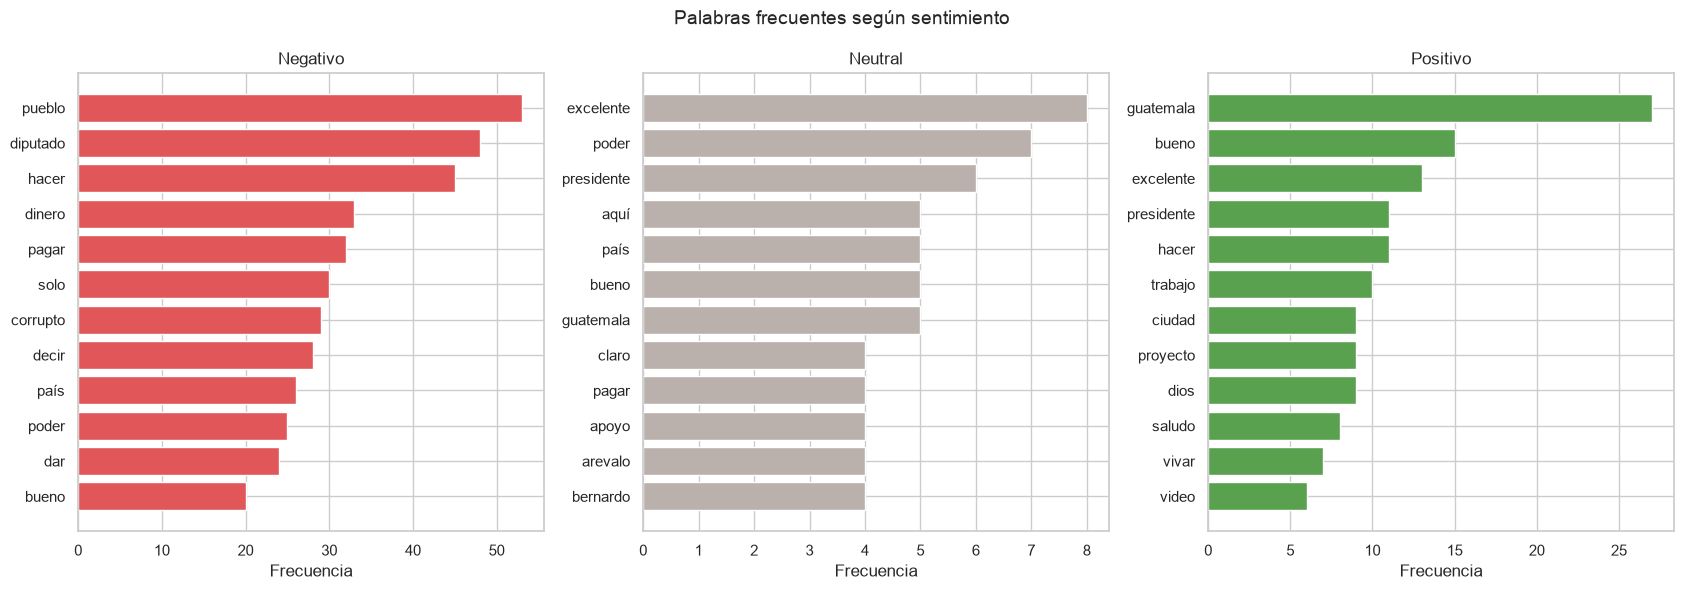

In [16]:
filas_palabras = []

for sentimiento, grupo in comments.groupby("sentimiento"):
    palabras = []

    for texto in grupo["texto_limpio"].dropna():
        palabras.extend(
            palabra
            for palabra in str(texto).split()
            if len(palabra) > 2
        )

    for palabra, frecuencia in Counter(
        palabras
    ).most_common(12):
        filas_palabras.append({
            "sentimiento": sentimiento,
            "palabra": palabra,
            "frecuencia": frecuencia
        })

palabras_sentimiento = pd.DataFrame(filas_palabras)

display(palabras_sentimiento)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(17, 6)
)

for ax, sentimiento in zip(
    axes,
    ORDEN_SENTIMIENTO
):
    datos = (
        palabras_sentimiento.query(
            "sentimiento == @sentimiento"
        )
        .sort_values("frecuencia")
    )

    ax.barh(
        datos["palabra"],
        datos["frecuencia"],
        color=colores[sentimiento]
    )

    ax.set_title(sentimiento)
    ax.set_xlabel("Frecuencia")
    ax.set_ylabel("")

plt.suptitle(
    "Palabras frecuentes según sentimiento",
    fontsize=14
)
plt.tight_layout()
plt.show()

In [17]:
display(
    comments["confianza_sentimiento"]
    .describe()
    .to_frame()
    .T
)

baja_confianza = comments.query(
    "confianza_sentimiento < 0.60"
)

print(
    f"Predicciones con confianza inferior a 0.60: "
    f"{len(baja_confianza)} de {len(comments)} "
    f"({len(baja_confianza) / len(comments):.1%})"
)

display(
    baja_confianza[
        [
            "texto_sentimiento",
            "sentimiento",
            "prob_negativo",
            "prob_neutral",
            "prob_positivo",
            "confianza_sentimiento"
        ]
    ]
    .sort_values("confianza_sentimiento")
    .head(20)
)

,count,mean,std,min,25%,50%,75%,max
confianza_sentimiento,406.0,0.812018,0.159668,0.354809,0.694416,0.87127,0.951427,0.985907


Predicciones con confianza inferior a 0.60: 67 de 406 (16.5%)


,texto_sentimiento,sentimiento,prob_negativo,prob_neutral,prob_positivo,confianza_sentimiento
404,Este hombre esta loco,Neutral,0.328996,0.354809,0.316195,0.354809
386,Ay ricos shucos en la calle jajaja,Negativo,0.435341,0.420121,0.144537,0.435341
248,No dejen que nuestros hermanos Guatemalatecos qué esten encerrados en esse lugar pir favor 🙏 Aut...,Negativo,0.451821,0.444593,0.103586,0.451821
295,"Excelente información, necesitaba saber y esta bastante claro... Ahora entiendo mejor 😢",Neutral,0.114259,0.453179,0.432563,0.453179
69,EL PRESIDENTE BERNARDO AREVALO SI ES UN PRESIDENTE QUE QUIERE A SU PUEBLO Y AL PAIS DE GUATEMALA...,Neutral,0.140700,0.467539,0.391761,0.467539
377,Mantenidos,Neutral,0.430597,0.470231,0.099172,0.470231
25,Pero hay que ver el lado bueno si los deportan por la Frontera los carteles los secuestran para ...,Neutral,0.465587,0.472741,0.061671,0.472741
120,"​ @eugeneramirez4405 \nGo away, there's no way to prove you're American.",Neutral,0.354315,0.472885,0.172799,0.472885
340,Despues de tanta corrpcion y desfalco por los anteriores gobiernos ladrones que esperaba Rolando...,Positivo,0.255848,0.271081,0.473071,0.473071
240,Ay que usarlos como mujeres,Neutral,0.155037,0.477768,0.367195,0.477768


In [18]:
muestras = []

for sentimiento, grupo in comments.groupby("sentimiento"):
    muestra = grupo.sample(
        n=min(10, len(grupo)),
        random_state=42
    )

    muestras.append(
        muestra[
            [
                "texto_sentimiento",
                "sentimiento",
                "confianza_sentimiento"
            ]
        ]
    )

muestra_revision = pd.concat(
    muestras,
    ignore_index=True
)

display(
    muestra_revision.sort_values(
        "sentimiento"
    )
)

,texto_sentimiento,sentimiento,confianza_sentimiento
0,No quiere hablar de sus almuerzos se molesta . No le creo . que,Negativo,0.933831
1,LADRONES !!!!,Negativo,0.581595
2,x eso es que estan bravos todos esos sinverguenzas xq ya no pueden hacer sus cochinadas ahora co...,Negativo,0.968358
3,Yo no entiendo por qué están ahorita con todas estas cosas por qué no lo hacían cuando estaban l...,Negativo,0.967539
4,Esa bancada Cabal y otros siguen en la terquedad de gastar en comida. A nadie le deben pagar su ...,Negativo,0.947300
5,Siguen con las mismas mañas....los diputados acostumbrados a estar de gorriones....,Negativo,0.933879
6,"Que comando mierd@ mejor de todas maneras tenemos que seguir trabajando, más gasto cuando ellos ...",Negativo,0.960017
7,No sé si todos los del Cabal son corruptos; pero Nery Rodas es un descarado corrupto.,Negativo,0.870131
8,"Si a los diputados no les alcanza el sueldo que se busquen otro trabajo, ya sea de los departam...",Negativo,0.886613
9,Otto Pérez Leal dejó tirado un paso a desnivel en Molino Las Flores y Neto Bran ni se ha molesta...,Negativo,0.660419


## Exportación

In [19]:
carpeta_salida = Path("data")
carpeta_salida.mkdir(
    parents=True,
    exist_ok=True
)

comments.to_csv(
    carpeta_salida / "youtube_comments_sentimiento.csv",
    index=False,
    encoding="utf-8-sig"
)

resumen_general.to_csv(
    carpeta_salida / "resumen_sentimiento.csv",
    index=False,
    encoding="utf-8-sig"
)

sentimiento_video.reset_index().to_csv(
    carpeta_salida / "sentimiento_por_video.csv",
    index=False,
    encoding="utf-8-sig"
)

sentimiento_canal.reset_index().to_csv(
    carpeta_salida / "sentimiento_por_canal.csv",
    index=False,
    encoding="utf-8-sig"
)

sentimiento_tema.reset_index().to_csv(
    carpeta_salida / "sentimiento_por_tema.csv",
    index=False,
    encoding="utf-8-sig"
)

sentimiento_comunidad.reset_index().to_csv(
    carpeta_salida / "sentimiento_por_comunidad.csv",
    index=False,
    encoding="utf-8-sig"
)

caracterizacion_comunidades.to_csv(
    carpeta_salida / "contenido_por_comunidad.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Resultados exportados correctamente.")

Resultados exportados correctamente.
